## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem](https://github.com/ga-bahrain/dsb-pt3-bahrain-2026/blob/main/modules/supervised-machine-learning/0.How%20to%20Frame%20a%20Data%20Science%20Problem/ML-Framing-a-Data-Science-Problem.pdf)
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Predicting Air Quality Categories in India
Data Source : https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india/data

# Problem Statement

Air pollution in Indian cities poses serious public health risks, but AQI-based warnings are often issued reactively rather than in advance. Using daily pollutant readings collected across Indian cities and monitoring stations, can we classify a day's air quality into its AQI category (Good, Satisfactory, Moderate, Poor, Very Poor, Severe) to help authorities and citizens take preventive action before exposure becomes dangerous? Success will be measured using macro F1-score to account for class imbalance, with particular focus on correctly identifying the higher-risk categories (Poor, Very Poor, Severe).

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

- What features influence the target variable (AQI category)?
- How much missing and duplicate data exists, and how should it be handled given 
  the time-series nature of the data?
- Can feature engineering (e.g. season) improve model performance?
- Given the class imbalance in AQI_Bucket, what evaluation metric will best 
  capture performance on the highest-risk categories?
- How do different model versions compare?

# Data Inspection

## Data Dictionary
| Column | Type | Description |
|--------|------|-------------|
| Location | str | City name or station ID of the measurement point |
| Date | str | Date of the air quality reading |
| PM2.5 | float | Fine particulate matter (diameter < 2.5 micrometers) in µg/m³ |
| PM10 | float | Coarse particulate matter (diameter < 10 micrometers) in µg/m³ |
| NO | float | Nitric oxide concentration in µg/m³ |
| NO2 | float | Nitrogen dioxide concentration in µg/m³ |
| NOx | float | Total nitrogen oxides (NO + NO2) in µg/m³ |
| NH3 | float | Ammonia concentration in µg/m³ |
| CO | float | Carbon monoxide concentration in mg/m³ |
| SO2 | float | Sulfur dioxide concentration in µg/m³ |
| O3 | float | Ground level ozone concentration in µg/m³ |
| Benzene | float | Benzene concentration in µg/m³ |
| Toluene | float | Toluene concentration in µg/m³ |
| Xylene | float | Xylene concentration in µg/m³ |
| AQI | float | Air Quality Index — numerical score summarizing overall air quality |
| AQI_Bucket | str | Air quality category: Good, Satisfactory, Moderate, Poor, Very Poor, Severe |

In [1]:
# organize your imports in this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [2]:
city = pd.read_csv('data/dataset_2/city_day.csv')
station = pd.read_csv('data/dataset_2/station_day.csv')

In [3]:
city = city.rename(columns={'City': 'Location'})
station = station.rename(columns={'StationId': 'Location'})

In [4]:
df = pd.concat([city, station], ignore_index=True)
df.shape

(137566, 16)

In [5]:
df.head()

,Location,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 137566 entries, 0 to 137565
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Location    137566 non-null  str    
 1   Date        137566 non-null  str    
 2   PM2.5       111343 non-null  float64
 3   PM10        83720 non-null   float64
 4   NO          116878 non-null  float64
 5   NO2         117434 non-null  float64
 6   NOx         117881 non-null  float64
 7   NH3         79133 non-null   float64
 8   CO          122509 non-null  float64
 9   SO2         108508 non-null  float64
 10  O3          107976 non-null  float64
 11  Benzene     100488 non-null  float64
 12  Toluene     90823 non-null   float64
 13  Xylene      34320 non-null   float64
 14  AQI         111875 non-null  float64
 15  AQI_Bucket  111875 non-null  str    
dtypes: float64(13), str(3)
memory usage: 16.8 MB


In [7]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,111343.000000,83720.000000,116878.000000,117434.000000,117881.000000,79133.000000,122509.000000,108508.000000,107976.000000,100488.000000,90823.000000,34320.000000,111875.000000
mean,77.401347,149.216375,21.891515,33.764851,39.284461,27.459017,1.749905,12.795828,37.274092,3.339665,13.773230,2.638668,176.798230
std,74.227329,118.158430,32.343375,28.609365,42.761826,25.191470,5.074937,14.403169,35.817444,12.422823,27.565512,6.430284,133.576567
min,0.020000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,31.070000,66.357500,5.040000,14.240000,13.720000,10.890000,0.530000,5.220000,18.887500,0.150000,0.670000,0.020000,85.000000
50%,54.150000,114.450000,10.175000,26.000000,25.880000,21.840000,0.910000,9.000000,30.840000,1.170000,3.860000,0.580000,128.000000
75%,95.300000,193.672500,23.690000,44.880000,48.190000,36.450000,1.450000,14.980000,46.720000,3.470000,14.960000,2.550000,244.000000
max,1000.000000,1000.000000,470.000000,448.050000,467.630000,418.900000,175.810000,195.650000,963.000000,455.030000,454.850000,170.370000,2049.000000


# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[us]')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.dropna(subset=['AQI_Bucket'])
df.shape

(111875, 16)

In [11]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct

Xylene        74.150615
NH3           32.507709
Toluene       28.737430
PM10          27.751508
Benzene       20.846480
O3             9.300559
SO2            9.061899
NOx            5.731397
PM2.5          3.723799
CO             2.986369
NO             2.338324
NO2            1.749274
Date           0.000000
Location       0.000000
AQI            0.000000
AQI_Bucket     0.000000
dtype: float64

In [12]:
df = df.drop(columns=['Xylene'])
df.shape

(111875, 15)

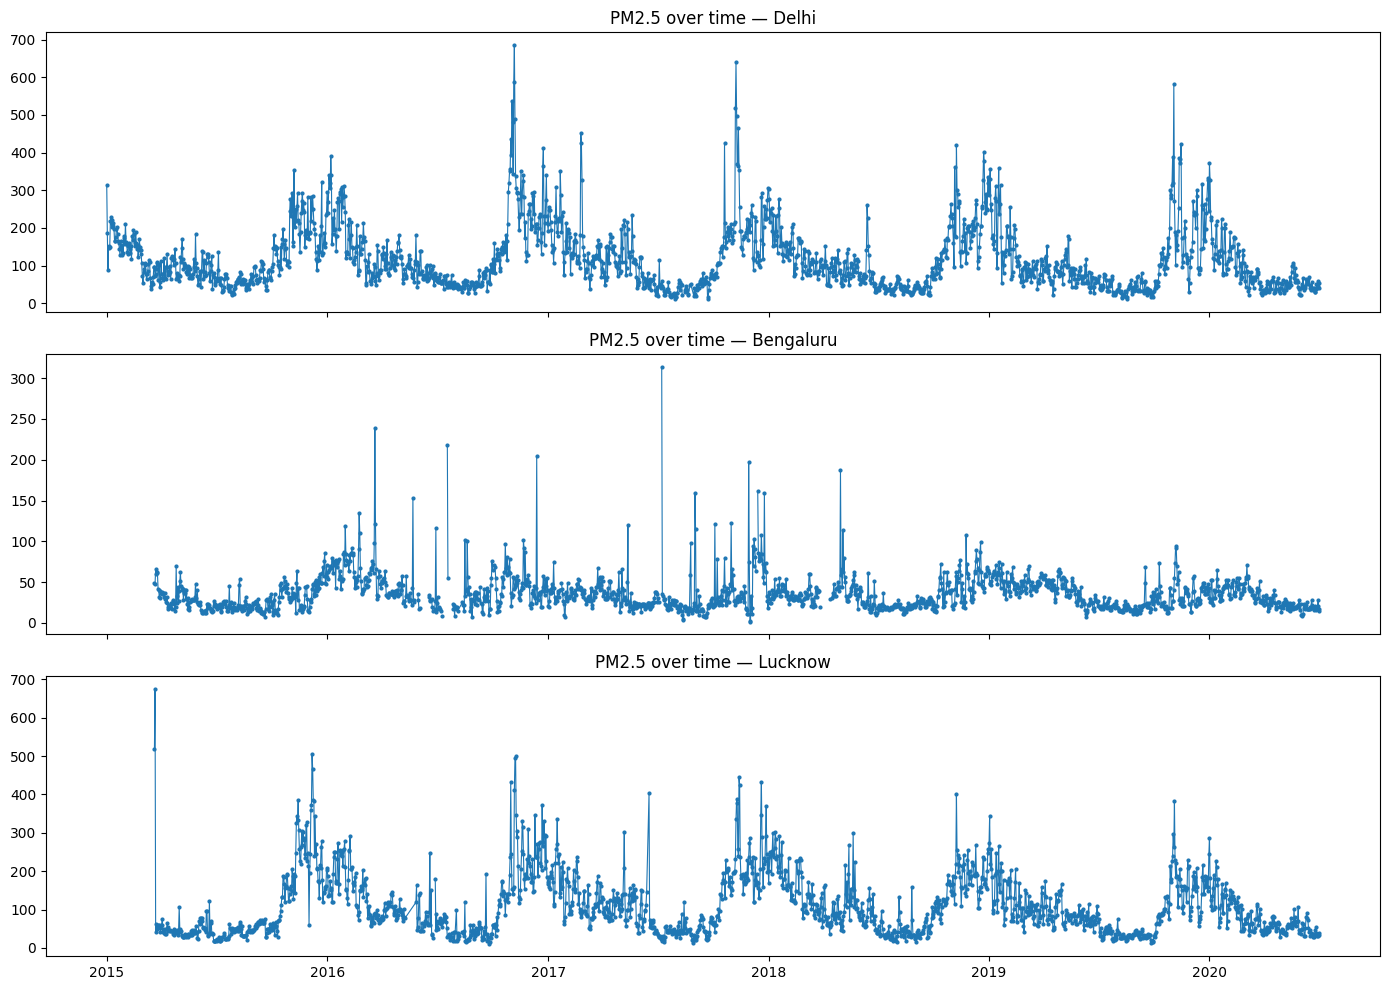

In [13]:
sample_locations = df['Location'].value_counts().head(3).index.tolist()

fig, axes = plt.subplots(len(sample_locations), 1, figsize=(14, 10), sharex=True)
for ax, loc in zip(axes, sample_locations):
    subset = df[df['Location'] == loc]
    ax.plot(subset['Date'], subset['PM2.5'], marker='o', markersize=2, linewidth=0.8)
    ax.set_title(f'PM2.5 over time — {loc}')
plt.tight_layout()
plt.show()

In [14]:
gap_check = df[df['Location'] == 'Delhi'][['Date', 'PM2.5']].copy()
gap_check['days_since_last'] = gap_check['Date'].diff().dt.days
gap_check['days_since_last'].describe()

count    1998.000000
mean        1.005005
std         0.113993
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: days_since_last, dtype: float64

In [15]:
for col in ['PM10', 'NH3', 'Toluene', 'Benzene', 'O3']:
    fully_missing_locations = df.groupby('Location')[col].apply(lambda x: x.isnull().all())
    n_locations = fully_missing_locations.sum()
    print(f"{col}: {n_locations} locations with 100% missing data")

PM10: 18 locations with 100% missing data
NH3: 27 locations with 100% missing data
Toluene: 34 locations with 100% missing data
Benzene: 19 locations with 100% missing data
O3: 8 locations with 100% missing data


In [16]:
df['Location'].nunique()

135

In [17]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

# Step 1: time-based interpolation within each location, capped at 5-day gaps
for col in pollutant_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.interpolate(method='linear', limit=5))

# Step 2: location-level median fallback
for col in pollutant_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.median()))

# Step 3: global median fallback for locations with zero data for a pollutant
for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

df[pollutant_cols].isnull().sum()

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [18]:
print((df['PM2.5'] == 1000).sum())
print((df['PM10'] == 1000).sum())

1
0


In [19]:
for col in ['PM2.5', 'PM10', 'AQI']:
    print(col)
    print(df[col].quantile([0.95, 0.99, 0.999, 1.0]))
    print()

PM2.5
0.950     225.04300
0.990     358.92260
0.999     554.81434
1.000    1000.00000
Name: PM2.5, dtype: float64

PM10
0.950    356.11300
0.990    535.16260
0.999    729.94126
1.000    976.77000
Name: PM10, dtype: float64

AQI
0.950     414.00
0.990     597.00
0.999    1217.63
1.000    2049.00
Name: AQI, dtype: float64



In [20]:
df[df['PM2.5'] == 1000]

,Location,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
76191,DL034,2017-02-27,1000.0,242.55,101.67,69.52,118.34,51.24,0.95,7.41,43.98,4.24,34.13,934.0,Severe


In [21]:
df[df['AQI'] == df['AQI'].max()]

,Location,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
1145,Ahmedabad,2018-02-19,242.66,108.125,132.47,199.17,246.03,22.075,132.47,127.725,44.06,0.74,5.81,2049.0,Severe
81933,GJ001,2018-02-19,242.66,108.125,132.47,199.17,246.03,22.075,132.47,127.725,44.06,0.74,5.81,2049.0,Severe


In [22]:
dupe_check = df[df.duplicated(subset=['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'AQI'], keep=False)]
dupe_check[['Location', 'Date', 'AQI']].sort_values('Date')

,Location,Date,AQI
28,Ahmedabad,2015-01-29,209.0
80816,GJ001,2015-01-29,209.0
80817,GJ001,2015-01-30,328.0
29,Ahmedabad,2015-01-30,328.0
30,Ahmedabad,2015-01-31,514.0
...,...,...,...
26956,Talcher,2020-07-01,101.0
28068,Thiruvananthapuram,2020-07-01,41.0
26031,Shillong,2020-07-01,24.0
86796,JH001,2020-07-01,86.0


In [23]:
check_cols = ['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
full_dupes = df.duplicated(subset=check_cols, keep=False)
full_dupes.sum()

np.int64(19520)

In [24]:
df = df.drop_duplicates(subset=check_cols, keep='first')
df.shape

(102115, 15)

In [25]:
df.isnull().sum()

Location      0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

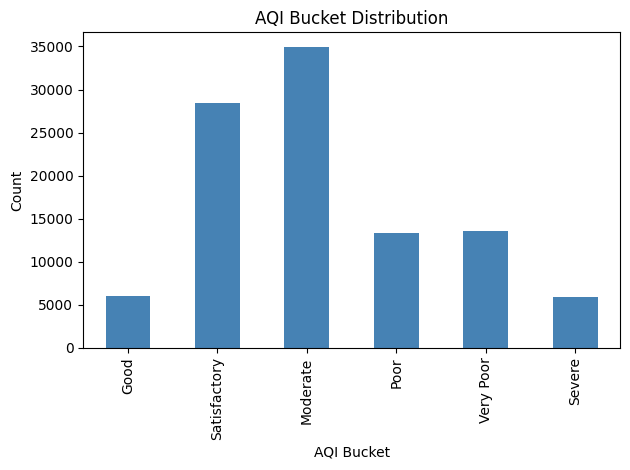

In [26]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
df['AQI_Bucket'].value_counts()[order].plot(kind='bar', color='steelblue')
plt.title('AQI Bucket Distribution')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.tight_layout()
#plt.savefig(r'C:\Users\DELL\OneDrive\Desktop\aqib-dist.png', bbox_inches='tight', dpi=150)
plt.show()

In [27]:
df['AQI_Bucket'].value_counts(normalize=True)[order] * 100

AQI_Bucket
Good             5.896293
Satisfactory    27.839201
Moderate        34.178132
Poor            13.079371
Very Poor       13.275229
Severe           5.731773
Name: proportion, dtype: float64

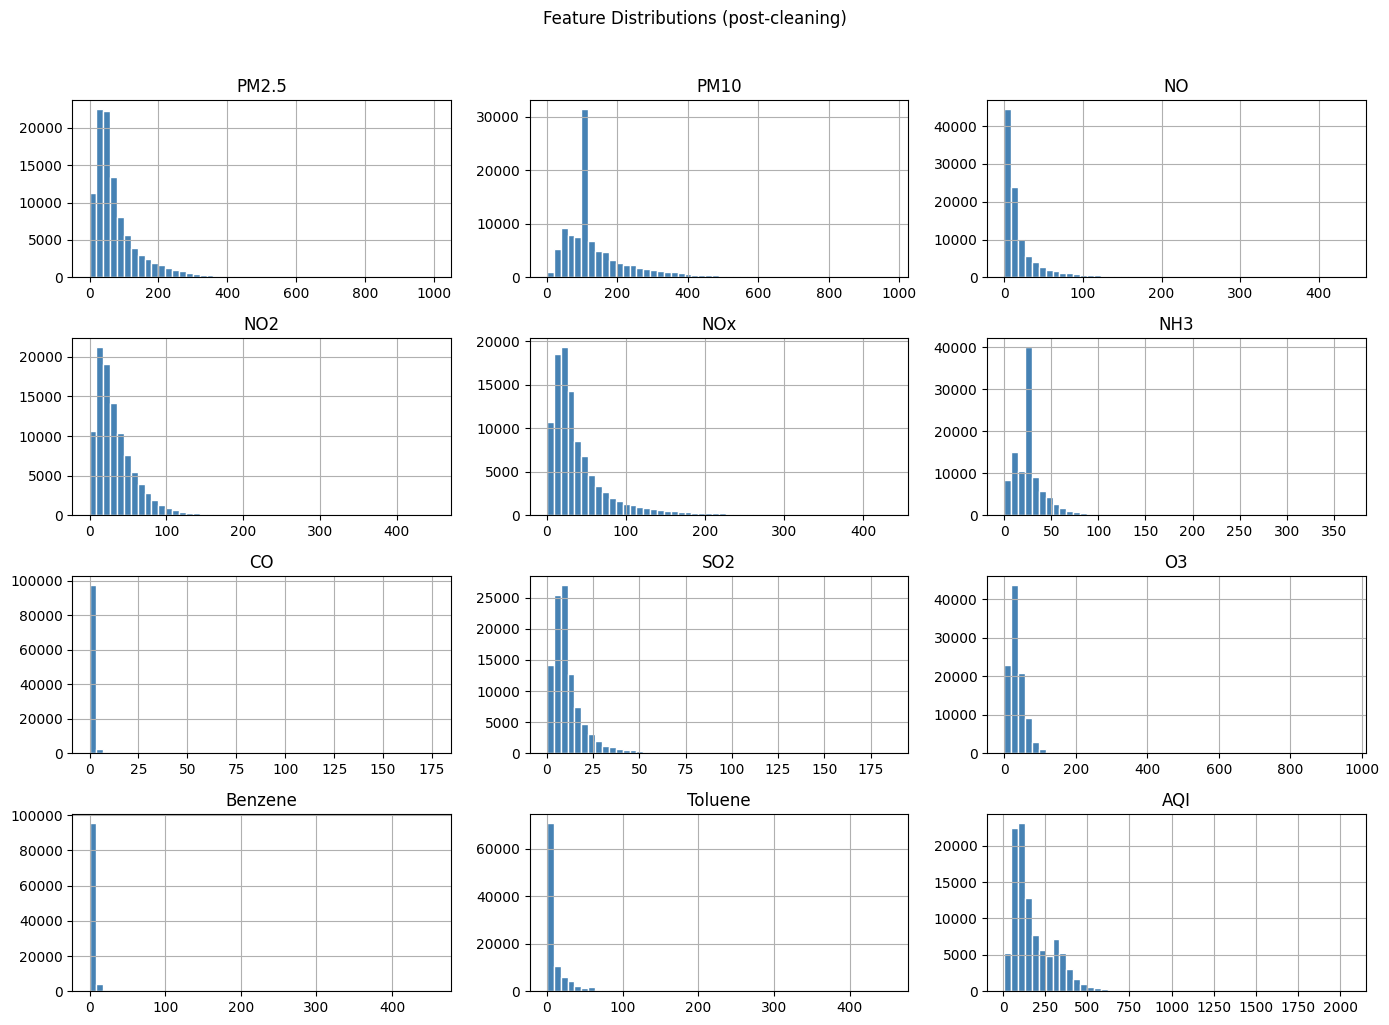

In [28]:
num_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
df[num_cols].hist(figsize=(14, 10), bins=50, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions (post-cleaning)', y=1.02)
plt.tight_layout()
plt.show()

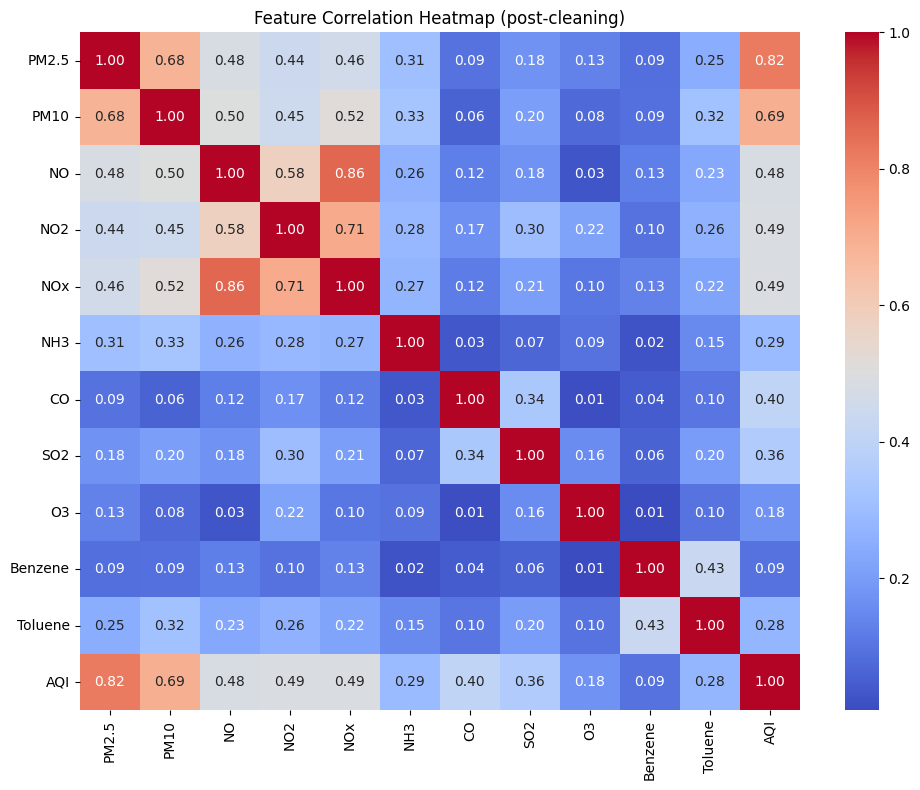

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap (post-cleaning)')
plt.tight_layout()
#plt.savefig(r'C:\Users\DELL\OneDrive\Desktop\heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

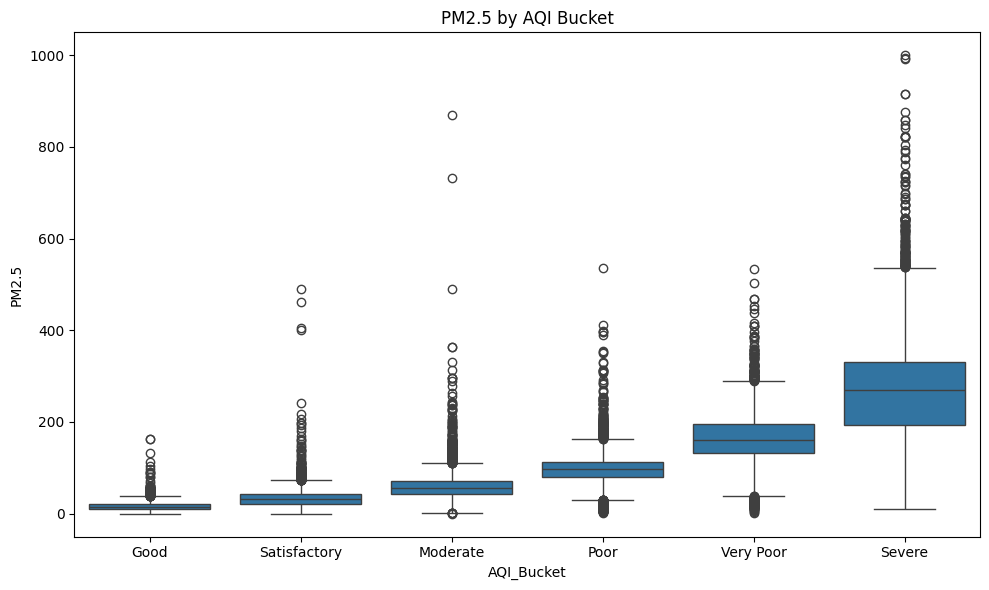

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='AQI_Bucket', y='PM2.5', order=order)
plt.title('PM2.5 by AQI Bucket')
plt.tight_layout()
#plt.savefig(r'C:\Users\DELL\OneDrive\Desktop\pm2.5.png', bbox_inches='tight', dpi=150)
plt.show()

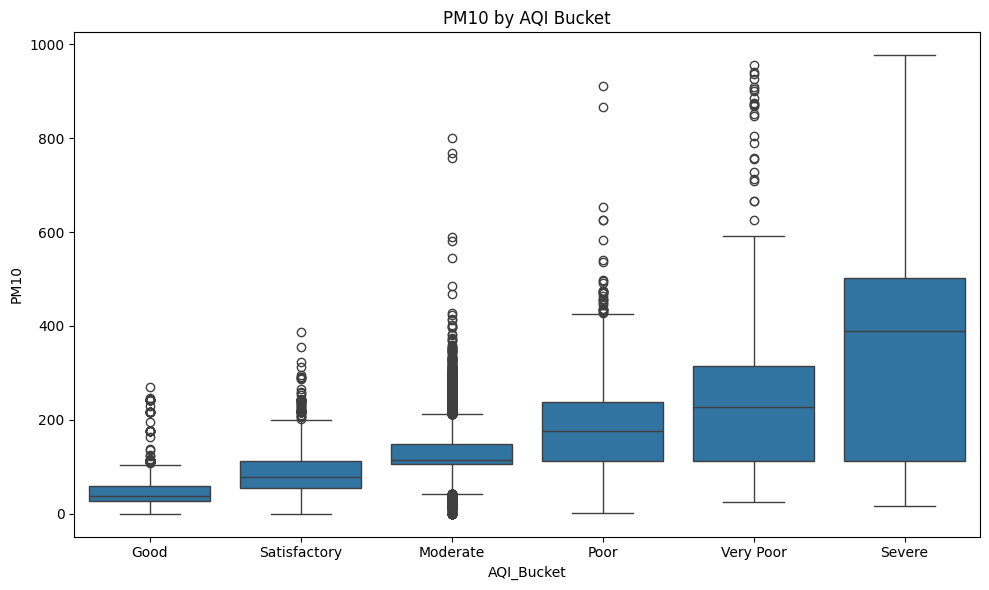

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='AQI_Bucket', y='PM10', order=order)
plt.title('PM10 by AQI Bucket')
plt.tight_layout()
#plt.savefig(r'C:\Users\DELL\OneDrive\Desktop\pm10.png', bbox_inches='tight', dpi=150)
plt.show()

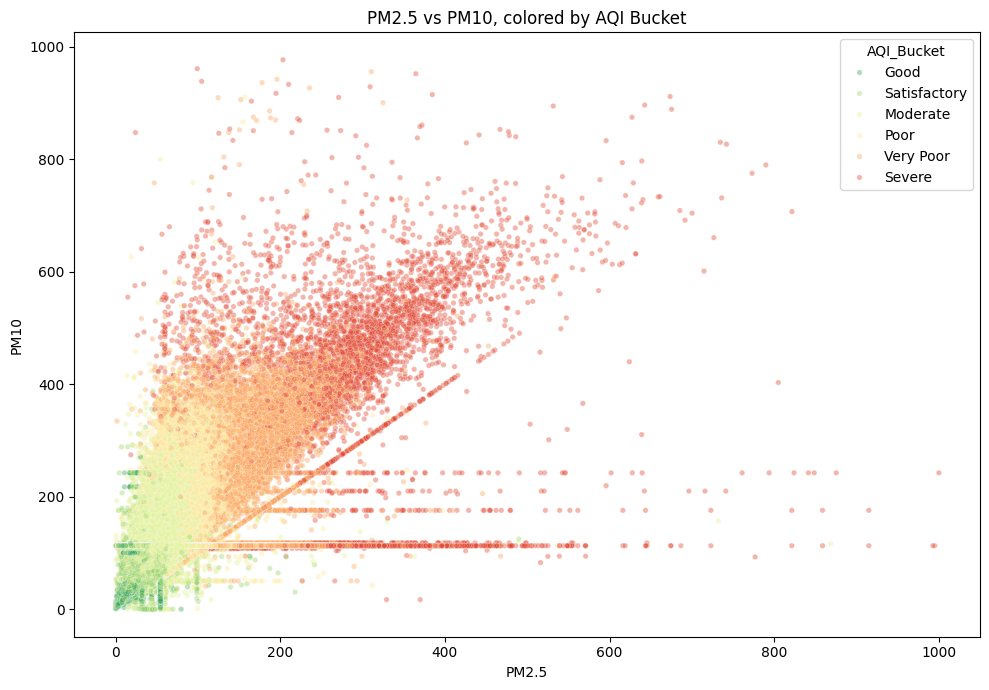

In [32]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='PM2.5', y='PM10', hue='AQI_Bucket', hue_order=order, 
                 palette='RdYlGn_r', alpha=0.4, s=15)
plt.title('PM2.5 vs PM10, colored by AQI Bucket')
plt.tight_layout()
#plt.savefig(r'C:\Users\DELL\OneDrive\Desktop\scatter.png', bbox_inches='tight', dpi=150)
plt.show()

In [33]:
df['PM10'].value_counts().head(10)

PM10
112.970    23649
50.450      1571
118.020     1271
108.125      932
175.840      683
242.550      393
77.525       248
94.330       232
210.090      100
99.880        50
Name: count, dtype: int64

In [34]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Date'].dt.month.apply(get_season)
df['Season'].value_counts()

Season
Monsoon         31361
Summer          28646
Winter          26119
Post-Monsoon    15989
Name: count, dtype: int64

In [35]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Season'], df['AQI_Bucket'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 24028.30132747896
p-value: 0.0


# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

Based on the EDA findings above, the following preprocessing steps are planned before modeling:

1. **Imputation flag for PM10**: Since ~23% of PM10 values were filled using the global median 
   (due to 18 stations with zero historical PM10 readings), a binary column PM10_was_imputed 
   will be created before modeling. This allows models to weigh PM10 differently when its value 
   is synthetic rather than measured.

2. **Drop leakage feature**: AQI will be removed from the feature set, since AQI_Bucket is 
   directly derived from it and including it would cause data leakage.

3. **Encode Location**: With 135 unique values, one-hot encoding would create excessive 
   dimensionality. Frequency encoding or dropping the column entirely will be evaluated as 
   alternatives.

4. **Feature engineer from Date**: Extract Month and/or Season, since EDA showed strong 
   seasonal pollution patterns (winter spikes across all three sampled locations). The raw Date 
   column will be dropped afterward.

5. **Scaling**: Pollutant columns are right-skewed (confirmed in histograms and boxplots). 
   StandardScaler (optionally after a log-transform) will be applied for distance-based models 
   (Logistic Regression, KNN, SVM). Tree-based models do not require scaling.

6. **Train/test split**: A stratified split on AQI_Bucket will be used to preserve class 
   proportions, given the class imbalance observed (Moderate 34%, Satisfactory 28%, down to 
   Good/Severe ~6% each).

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

This is a **multiclass classification** problem (6 target classes).

**Models to evaluate:**
- Logistic Regression — interpretable baseline
- Random Forest — robust to skew and imputation noise, provides feature importance
- KNN or SVM — comparison point

**Pipeline:** scikit-learn Pipeline combined with GridSearchCV and StratifiedKFold, consistent 
with prior coursework.

**Primary evaluation metric:** Macro F1-score, chosen to account for class imbalance without 
letting majority classes dominate the score. Per-class recall will also be tracked, with particular 
attention to Poor, Very Poor, and Severe, since these are the classes most relevant for public 
health action.

**Baseline for comparison:** A majority-class baseline (always predicting "Moderate") will be used 
to contextualize model performance gains.